# Bays (2024) Figure 5 — Diagnosing the $\mathrm{SD}_{\mathrm{normal}}$ Plateau (Bays vs GP)

**Goal.** Reproduce Figure 5 of Ma, Husain & Bays (2014, *Nat Neurosci*) using **two model pipelines run in parallel** under the same diagnostic protocol:

1. **Bays (2014) parametric population coding model.**
2. **Our GP-based population coding model.**

This is the same Bays-vs-GP equivalence comparison used throughout the thesis. Here it is applied to the $\mathrm{SD}_{\mathrm{normal}}$-plateau diagnostic: a methodological test that asks whether a particular way of *summarising* recall errors can be trusted to distinguish between competing accounts of working memory.

### What Figure 5 is about

A popular analysis pipeline for visual working memory data fits the Zhang & Luck (2008) **normal–uniform mixture**

$$
p(\epsilon) \;=\; w \cdot \mathrm{VonMises}(\epsilon;\, 0, \kappa) \;+\; (1-w) \cdot \frac{1}{2\pi}.
$$

From the fitted $\kappa$ one reads off $\mathrm{SD}_{\mathrm{normal}}$, intended as the precision of "stored" items, while $1-w$ is interpreted as the "guess" rate. Figure 5 of Ma, Husain & Bays (2014) shows that as set size $\ell$ grows:

- $\mathrm{SD}_{\mathrm{actual}}$ (the model-free circular SD of the raw errors) climbs steeply,
- $\mathrm{SD}_{\mathrm{normal}}$ (read off the fitted mixture) rises and then *plateaus*,
- $w$ drops — the mixture starts attributing errors to "guessing".

The plateau was used to argue for slot models: *"precision is fixed, extra items just fail to be stored."* The original paper's Figure 5(c) rebuts this by showing the same plateau pattern is produced by a continuous-resource model that contains **no slots and no item limit** — confirming the plateau is an artifact of fitting a misspecified mixture, not a signature of slots.

### What this notebook does

Both model pipelines are continuous-resource population coding models without slots. Running both through the identical diagnostic pipeline lets us check two things at once:

- That **each** model independently reproduces the $\mathrm{SD}_{\mathrm{normal}}$ plateau (so the diagnostic conclusion in Ma, Husain & Bays 2014 carries over to both architectures).
- That the **Bays and GP variants** produce quantitatively similar $\mathrm{SD}_{\mathrm{actual}}$ / $\mathrm{SD}_{\mathrm{normal}}$ curves under the protocol — the equivalence check that anchors the thesis.

### Layout

- **Row 1 — Bays parametric.** (a) aggregate-error distribution + mixture fit. (b) $\mathrm{SD}_{\mathrm{actual}}$ vs $\mathrm{SD}_{\mathrm{normal}}$ across set sizes.
- **Row 2 — GP variant.** Same two panels for the GP-based population.

### Note on the citation

The paper is Ma, Husain & Bays (2014, *Nat Neurosci*); a number of internal references in this project use the shorthand "Bays 2024" for the 2024 review article that re-presents the same figure. The diagnostic logic and figure are from the 2014 paper.

## GP Pipeline Comparison with Bays

**Experiment 1.** Run the Bays (2014) parametric population-coding model and the GP-based population model through the identical $\mathrm{SD}_{\mathrm{normal}}$-plateau diagnostic, and check that the two architectures behave equivalently. Everything below (setup, both forward models, the parameter fit, the set-size sweeps, and the headline Figure 5 reproduction) belongs to this experiment.

### Imports & setup

In [106]:
import sys
from pathlib import Path
from datetime import datetime

# Project root is two levels above this notebook
# (notebook lives in equivalence_model_v0.1/experiments/<something>/).
PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import i0, i1
from scipy.optimize import minimize, least_squares

from core.population import Population

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


### Output directory

Results (figure + per-set-size summary) go to `result_data/bays_fig5_<timestamp>/`, matching the project's convention used by the other experiment notebooks.

In [107]:
import uuid

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_UUID  = str(uuid.uuid4())          # unique id for this run; stamped into the fit DB

# Save beside the notebook, inside THIS experiment's own folder
# (experiments/<experiment>/result_data/...). The 8-char UUID suffix links
# the folder to its row in the fit database.
EXPERIMENT_DIR = Path.cwd()
OUTPUT_DIR = EXPERIMENT_DIR / "result_data" / f"bays_fig5_{TIMESTAMP}_{RUN_UUID[:8]}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Persistent fit database: accumulates ONE row per run (NOT timestamped, so
# it survives across runs and kernels). Created with a header on first use.
FIT_DB_PATH = EXPERIMENT_DIR / "fit_database.csv"

print(f"Experiment dir  : {EXPERIMENT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Run UUID        : {RUN_UUID}")
print(f"Fit database    : {FIT_DB_PATH}")

Experiment dir  : /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024
Output directory: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687
Run UUID        : 6dc0e687-df16-4a26-b49e-ba2306c95a60
Fit database    : /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/fit_database.csv


### Circular statistics and the Zhang & Luck mixture fit

In [108]:
def circular_sd(errors):
    """Fisher (1995) circular SD: sigma = sqrt(-2 log |m1|)."""
    R = np.abs(np.mean(np.exp(1j * np.asarray(errors))))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def kappa_to_circular_sd(kappa):
    """Von Mises concentration kappa -> Fisher circular SD."""
    if kappa < 1e-6:
        return np.sqrt(-2.0 * np.log(1e-15))
    if kappa > 700:
        kappa = 700.0
    R = float(i1(kappa) / i0(kappa))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def _neg_log_lik_mixture(unconstrained_params, errors):
    """Negative log likelihood of the normal-uniform mixture, with logit/log transforms."""
    logit_w, log_kappa = unconstrained_params
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)

    vm = np.exp(kappa * np.cos(errors)) / (2.0 * np.pi * i0(kappa))
    uniform = 1.0 / (2.0 * np.pi)
    mix = w * vm + (1.0 - w) * uniform

    return -np.sum(np.log(np.maximum(mix, 1e-300)))


def fit_normal_uniform_mixture(errors, init_w=0.85, init_kappa=10.0):
    """
    ML fit of the Zhang & Luck (2008) normal-uniform mixture.

    Returns
    -------
    w : float in (0, 1)
        Weight on the Von Mises ("stored") component.
    kappa : float > 0
        Von Mises concentration.
    sd_normal : float
        Circular SD corresponding to kappa.
    """
    errors = np.asarray(errors)
    logit_w0 = np.log(init_w / (1.0 - init_w))
    log_kappa0 = np.log(init_kappa)
    x0 = np.array([logit_w0, log_kappa0])

    result = minimize(
        _neg_log_lik_mixture, x0, args=(errors,),
        method="Nelder-Mead",
        options={"xatol": 1e-6, "fatol": 1e-6, "maxiter": 5000},
    )
    logit_w, log_kappa = result.x
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)
    sd_normal = kappa_to_circular_sd(kappa)
    return w, kappa, sd_normal


# Sanity check: a pure von Mises should give w ~ 1, SD_actual ~ SD_normal
rng_test = np.random.RandomState(0)
test_errors = rng_test.vonmises(0, 5.0, size=5000)
w_hat, k_hat, sd_n_hat = fit_normal_uniform_mixture(test_errors)
print("Sanity check (pure VM with kappa=5):")
print(f"  fitted w={w_hat:.3f} (should be near 1), kappa={k_hat:.2f} (should be ~5)")
print(f"  SD_actual={np.rad2deg(circular_sd(test_errors)):.2f} deg, "
      f"SD_normal={np.rad2deg(sd_n_hat):.2f} deg  (should be ~equal)")


Sanity check (pure VM with kappa=5):
  fitted w=1.000 (should be near 1), kappa=5.07 (should be ~5)
  SD_actual=26.99 deg, SD_normal=26.99 deg  (should be ~equal)


### Bays parametric pipeline

Standalone implementation of Bays (2014, *J Neurosci*) Experiment 1 — pure NumPy, no `core.*` dependencies. Same forward model as the Bays-2014 reference used in the rest of the thesis.

| Bays equation | What it does |
|---|---|
| Eq. 1 | Tuning: $f_i(\theta) = \exp(\omega^{-1}(\cos(\phi_i - \theta) - 1))$ |
| Eq. 2 / 3 | DN: $r_{ij} = \gamma \cdot f_{ij} / \sum_{m,n} f_{mn}$ |
| Eq. 4 | Independent Poisson spike counts over $T_d$ |
| Eqs. 5–8 | ML decoder: $\hat\theta = \arg\max_\theta \sum_i n_i \cos(\phi_i - \theta)$ |

Three details to flag: (i) **no** semi-saturation $\sigma^2$ in the DN denominator (Bays Eq. 2 has none); (ii) continuous orientation sampling (no encoding-grid quantisation); (iii) random tie-breaking in `argmax` per Bays's explicit spec.

In [109]:
def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    M=100, rng=None, n_decode_grid=1000):
    """
    Vectorised batch implementation of Bays (2014) Experiment 1 pipeline.

    Returns signed circular errors of shape (n_trials,) in radians on [-pi, pi).
    """
    if rng is None:
        rng = np.random.RandomState()

    l = set_size
    phi = np.linspace(-np.pi, np.pi, M, endpoint=False)

    # 1-2. Sample stimuli
    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))
    cued = rng.randint(l, size=n_trials)

    # 3. Eq. 1 driving inputs
    diff = phi[None, None, :] - theta_true[:, :, None]
    f = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))

    # 4. DN -- denom is per-trial sum over (l, M)
    denom = f.sum(axis=(1, 2))
    rates = gamma_total * f / denom[:, None, None]

    # 5. Poisson spikes
    counts = rng.poisson(rates * T_d)

    # 6. Pull out probed subpopulation
    counts_probed = counts[np.arange(n_trials), cued, :]

    # ML decode (vectorised over trials)
    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid = np.cos(phi[:, None] - theta_eval[None, :])
    objective = counts_probed @ cos_grid

    # Random tie-breaking
    max_vals = objective.max(axis=1, keepdims=True)
    tied_mask = objective >= max_vals - 1e-12
    keys = rng.random(objective.shape) * tied_mask
    chosen_idx = keys.argmax(axis=1)
    theta_hat = theta_eval[chosen_idx]

    # 7. Signed circular error
    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


print("Defined: bays_run_trials")


Defined: bays_run_trials


### GP forward model

Routes through the unified `Population` class (`tuning_type='gp'`). `Population.run_trials` performs the same vectorised batch encode-and-decode as `bays_run_trials`: it samples `set_size` orientations on a deterministic location tuple, applies population-level divisive normalisation, generates Poisson spikes, and returns signed circular errors via the ML decoder. Setting `active_locations=tuple(range(set_size))` and `probe_cued=True` matches the convention of probing location 0 on every trial.

In [110]:
def build_gp_population(M, n_theta, omega, n_locations, seed,
                        lengthscale_variability=0.3, gain_variability=0.0,
                        method='folded_normal'):
    """
    Construct the heterogeneous GP population used downstream.

    Bays's tuning width `omega` maps to the GP lengthscale internally via
    `lambda = sqrt(omega)` (handled inside `Population._build_gp`).

    `method` selects the lengthscale sampler family ('folded_normal' or
    'gamma'); it is forwarded to Population so the same call site can
    switch sampler without touching the GP sweep cell.
    """
    return Population(
        M=M,
        n_theta=n_theta,
        omega=omega,
        tuning_type="gp",
        n_locations=n_locations,
        seed=seed,
        lengthscale_variability=lengthscale_variability,
        gain_variability=gain_variability,
        method=method,
    )


print("Defined: build_gp_population")


Defined: build_gp_population


### Configuration — all tunable knobs in one cell

Edit this single cell to change any experimental knob. Defaults follow Bays (2014) Experiment 1 group-mean ML parameters: $\omega = 0.52$, $\gamma_\mathrm{total} = 119$ Hz, $M = 100$, $T_d = 0.1$ s. The $\omega \leftrightarrow \lambda$ mapping ($\lambda = \sqrt{\omega}$) and the gain conversion ($\gamma_\mathrm{per\ neuron} = \gamma_\mathrm{total} / M$) make the GP variant numerically comparable to the Bays parametric model.

Re-run from this cell to apply changes — the model definitions above don't need to be touched.

In [111]:
# =============================================================
# === PARAMETERS - edit here to play with the experiment    ===
# =============================================================

# --- Shared (both Bays parametric and GP variant) ---
M = 1000                           # THE single global neuron count for BOTH pipelines.
                                  #   Allowed: 100 / 1000 / 10000 (matches the Bays cache grid).
assert M in (100, 1000, 10000), f"M must be 100 / 1000 / 10000, got {M}."
DISTRIBUTION = 'sparse_broad'   # <-- SET ME: 'folded_normal' | 'gamma' | 'sparse_broad'

print(f'DISTRIBUTION = {DISTRIBUTION!r}')
assert DISTRIBUTION in ('folded_normal', 'gamma', 'sparse_broad'), (
    f"DISTRIBUTION must be 'folded_normal' / 'gamma' / 'sparse_broad', "
    f"got {DISTRIBUTION!r}"
)
N_TRIALS = 5000                   # trials per set size (per model)
T_D = 0.1                         # decoding window (s)
SET_SIZES = list(range(1, 9))     # set sizes to sweep: 1, 2, ..., 8
SEED = 42

# --- Bays parametric model ---
OMEGA_BAYS = 0.52                 # tuning width (group-mean ML fit, Bays 2014 Fig 2b)
GAMMA_TOTAL_BAYS = 119.0          # total population gain (Hz)
N_DECODE_GRID = 1000              # orientation grid for Bays ML decoder

# --- Bays reference source: regenerate inline, or load cached .npz ---
# The cache is produced by build_bays_cache.py. Bays errors are M-invariant
# (Bays 2014: "error distributions were independent of population size"), so
# any cached M is a valid reference; the loader matches M for clarity.
# NOTE: the cache must cover every entry in SET_SIZES. The shipped builder
# only caches [1, 2, 4, 8]; rebuild it with SET_SIZES = list(range(1, 9))
# before flipping this to True, or the loader falls back to inline generation.
USE_BAYS_CACHE = False            # <-- set True once the cache covers all SET_SIZES
CACHE_DIR = PROJECT_ROOT / "cached_data"   # <-- confirm / override to your cached_data path

# --- GP variant ---
N_THETA_GP = 128                  # orientation grid resolution for GP tuning curves
LENGTHSCALE_VARIABILITY = 0.3     # spread of GP lengthscales across locations
GAIN_VARIABILITY = 0.0            # spread of amplitude scaling (0 = homogeneous)
SIGMA_SQ = 1e-6                   # DN semi-saturation constant

# --- Histogram (panel a) ---
HIST_N_BINS = 120                 # ~3 deg bins over [-180, 180]

# --- Derived (don't edit directly) ---
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)
GAMMA_PER_NEURON = GAMMA_TOTAL_BAYS / M

print("=== Configuration ===")
print(f"M = {M} neurons (global, Bays AND GP),  T_D = {T_D}s,  N_TRIALS = {N_TRIALS} per set size")
print(f"Set sizes: {SET_SIZES}")
print()
print("Bays parametric:")
print(f"  omega = {OMEGA_BAYS}")
print(f"  gamma_total = {GAMMA_TOTAL_BAYS} Hz")
print(f"  decode grid = {N_DECODE_GRID}")
print(f"  reference source = {'cache (.npz)' if USE_BAYS_CACHE else 'inline'}")
print()
print("GP variant:")
print(f"  lambda = sqrt(omega) = {LAMBDA_BASE:.4f}")
print(f"  gamma_per_neuron = gamma_total / M = {GAMMA_PER_NEURON:.3f} Hz")
print(f"  n_theta = {N_THETA_GP}")
print(f"  lengthscale_variability = {LENGTHSCALE_VARIABILITY}")
print(f"  gain_variability = {GAIN_VARIABILITY}")
print()
print(f"Histogram bins (panel a): {HIST_N_BINS}  (~{360/HIST_N_BINS:.1f} deg wide)")

DISTRIBUTION = 'sparse_broad'
=== Configuration ===
M = 1000 neurons (global, Bays AND GP),  T_D = 0.1s,  N_TRIALS = 5000 per set size
Set sizes: [1, 2, 3, 4, 5, 6, 7, 8]

Bays parametric:
  omega = 0.52
  gamma_total = 119.0 Hz
  decode grid = 1000
  reference source = inline

GP variant:
  lambda = sqrt(omega) = 0.7211
  gamma_per_neuron = gamma_total / M = 0.119 Hz
  n_theta = 128
  lengthscale_variability = 0.3
  gain_variability = 0.0

Histogram bins (panel a): 120  (~3.0 deg wide)


### Sweep the Bays parametric model across set sizes

For each $l$, generate `N_TRIALS` errors, then compute $\mathrm{SD}_{\mathrm{normal}}$ and fit the Zhang & Luck mixture to extract $\mathrm{SD}_{\mathrm{normal}}$nd $w$.

In [112]:
def _bays_cache_path(cache_dir, M, n_trials=10000, omega=OMEGA_BAYS,
                     gamma_total=GAMMA_TOTAL_BAYS, seed=12345):
    """Canonical Bays cache filename -- MUST match build_bays_cache.py."""
    return Path(cache_dir) / (
        f"bays_cache_omega{omega:g}_gamma{gamma_total:g}"
        f"_M{M}_N{n_trials}_seed{seed}.npz"
    )


def load_bays_errors_from_cache(cache_dir, M, set_sizes):
    """Return {set_size: errors} from a cache .npz, or None if unusable.

    Requires the cache to cover EVERY requested set size; otherwise returns
    None so the caller falls back to inline generation. We deliberately do
    NOT silently mix cached and freshly-generated set sizes.
    """
    path = _bays_cache_path(cache_dir, M)
    if not path.exists():
        print(f"[cache] not found: {path.name}  ->  regenerating inline")
        return None
    with np.load(path, allow_pickle=True) as z:
        have = {int(k.split("_N")[1]) for k in z.files if k.startswith("errors_N")}
        missing = [N for N in set_sizes if N not in have]
        if missing:
            print(f"[cache] {path.name} missing set sizes {missing} "
                  f"(has {sorted(have)})  ->  regenerating inline. "
                  f"Rebuild with SET_SIZES=list(range(1,9)) for full coverage.")
            return None
        errs = {N: z[f"errors_N{N}"] for N in set_sizes}
    print(f"[cache] loaded {path.name}  (set sizes {set_sizes})")
    return errs


t0 = time.time()
bays_results = {}

cached = load_bays_errors_from_cache(CACHE_DIR, M, SET_SIZES) if USE_BAYS_CACHE else None
BAYS_SOURCE = "cache" if cached is not None else "inline"

rng_bays = np.random.RandomState(SEED)
for N in SET_SIZES:
    if cached is not None:
        errors = cached[N]
    else:
        errors = bays_run_trials(
            n_trials=N_TRIALS, set_size=N,
            omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, T_d=T_D,
            M=M, rng=rng_bays, n_decode_grid=N_DECODE_GRID,
        )
    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)
    bays_results[N] = dict(
        errors=errors, sd_actual=sd_actual, sd_normal=sd_normal,
        w=w_hat, kappa=kappa_hat,
    )
    print(f"  Bays l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   "
          f"SD_normal={np.rad2deg(sd_normal):6.2f} deg   "
          f"w={w_hat:.3f}   kappa={kappa_hat:.2f}")
print(f"Bays sweep ({BAYS_SOURCE}) done in {time.time()-t0:.1f}s")

  Bays l=1:  SD_actual= 15.61 deg   SD_normal= 15.45 deg   w=0.998   kappa=14.27
  Bays l=2:  SD_actual= 24.74 deg   SD_normal= 22.56 deg   w=0.982   kappa=6.99
  Bays l=3:  SD_actual= 32.54 deg   SD_normal= 26.81 deg   w=0.945   kappa=5.13
  Bays l=4:  SD_actual= 39.45 deg   SD_normal= 30.03 deg   w=0.899   kappa=4.23
  Bays l=5:  SD_actual= 44.53 deg   SD_normal= 32.45 deg   w=0.864   kappa=3.72
  Bays l=6:  SD_actual= 50.36 deg   SD_normal= 34.79 deg   w=0.813   kappa=3.33
  Bays l=7:  SD_actual= 54.46 deg   SD_normal= 35.98 deg   w=0.774   kappa=3.16
  Bays l=8:  SD_actual= 57.89 deg   SD_normal= 37.56 deg   w=0.740   kappa=2.96
Bays sweep (inline) done in 6.3s


### Sweep the GP variant across set sizes

#### GP experiment control

These flags govern the GP variant: first a fit of $(\lambda, \gamma, \sigma)$ against the Bays errors, then a GP sweep across set sizes at those fitted parameters. The Bays parametric sweep above is unaffected.

**`M_GP`** is the number of neurons for the GP population. Suggested values: `100` (primary reference, fast), `1000` (M-scaling diagnostic, slower), `10000` (large-M asymptotic, slowest).

**`DISTRIBUTION`** chooses how lengthscales are sampled across locations inside the GP forward model: `'folded_normal'` or `'gamma'`. The single $\sigma$ parameter (interpreted per-sampler) is a **scalar** — fitted once and applied uniformly across all locations.

The downstream Zhang & Luck mixture is fit to **GP errors generated at the fitted parameters**, not at Bays's raw $(\omega = 0.52, \gamma = 119)$ — so panels c/d test whether the GP-as-fit-to-Bays reproduces the same plateau, rather than testing whether an arbitrary GP at Bays-truth parameters does.


In [113]:
# === GP CONTROL (1/3): neuron count ===
# CONSOLIDATED: there is a single global `M` (set in the parameters cell
# above), used by BOTH the Bays and GP pipelines. There is no separate
# M any more -- the 100-vs-1000-vs-10000 comparison is driven entirely
# by the one global M.
print(f"M (global, used by Bays AND GP) = {M}")

M (global, used by Bays AND GP) = 1000


In [114]:
# === GP CONTROL (3/3): resolved derived quantities ===
# Reads M and DISTRIBUTION from the cells above. Re-run this (and the GP
# cells below) after changing either.

GAMMA_PER_NEURON_GP = GAMMA_TOTAL_BAYS / M

print('=== GP experiment control resolved ===')
print(f'  M                   = {M}')
print(f'  DISTRIBUTION        = {DISTRIBUTION!r}')
print(f'  gamma_per_neuron_gp = {GAMMA_PER_NEURON_GP:.4f} Hz '
      f'(total stays at {GAMMA_TOTAL_BAYS} Hz)')

=== GP experiment control resolved ===
  M                   = 1000
  DISTRIBUTION        = 'sparse_broad'
  gamma_per_neuron_gp = 0.1190 Hz (total stays at 119.0 Hz)


#### Step 1 — Fit GP $(\lambda, \gamma, \sigma)$ to Bays errors

Fits the GP forward model's three free parameters to the Bays error histograms (generated in the previous cell), set size by set size, by minimising bin-wise residuals across all set sizes simultaneously. $\sigma$ (i.e. `sigma_lambda` for `folded_normal` or `cv` for `gamma`) is a **scalar** free parameter — one value fitted, applied across all locations.

The fitted $(\hat\lambda, \hat\gamma, \hat\sigma)$ then drive the GP sweep below.

**Notes on convergence.** The forward model is stochastic (random GP populations + Poisson trials), which can corrupt finite-difference Jacobians and stall the optimizer. Three safeguards: (a) the per-call RNG seed is **pinned**, so identical parameters produce identical errors and the Jacobian sees only the parameter sensitivity; (b) `N_TRIALS_FIT = 5000` keeps the residual sharp; (c) starting point seeded near the Bays target so the optimizer explores the recovery basin from inside it.


In [115]:
# === Step 1 — Fit GP (lambda, gamma, sigma) to Bays errors ===
# Same procedure as the Figure 2 unified fit: histogram-bin least-squares
# residuals across all set sizes simultaneously. The single sigma parameter
# (sigma_lambda for folded_normal, CV for gamma) is a scalar — held fixed
# across set sizes and locations during the fit (no per-location array).

# --- Fit configuration ---
# Why these numbers:
#   N_TRIALS_FIT = 5000 (not 1000): the forward model is stochastic, and
#     a noisy residual drowns the finite-difference Jacobian. At 1000 trials
#     the optimizer terminates after one step with parameters unchanged.
#     5000 trials/set-size × 8 set sizes = 40k trials per forward call —
#     manageable wall time, sharp residuals.
#   SEED_FIT pinned: every forward call uses the SAME seed offset so that
#     identical parameters produce identical errors. This makes the residual
#     a deterministic function of the parameters — without this, finite
#     differences are corrupted by trial-to-trial noise even with large
#     N_TRIALS_FIT.
#   xtol/ftol/gtol relaxed: the default 1e-8 is unreachable on a stochastic
#     forward; 1e-4 lets the optimizer actually iterate rather than quit on
#     the first plateau.
N_TRIALS_FIT = 5000
SEED_FIT     = SEED
N_BINS_FIT   = 50
BIN_EDGES    = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
# M_FIT is a FIXED calibration reference, NOT a second experiment knob.
# Bays/GP errors depend only on TOTAL gain, not neuron count (Bays 2014:
# "error distributions were independent of population size"), so we
# calibrate gamma on a cheap M_FIT=100 population and rescale to the
# global M. When M == 100 (default) this reference IS the experiment
# population, so nothing is approximated in the common case; for larger
# M it keeps the fit fast while total activity is rescaled exactly.
M_FIT = 100
# Optimiser bounds and starting points depend on the chosen sampler.
# Starting point now seeded near the Bays target so the optimizer
# explores around the recovery basin rather than at an arbitrary
# (lambda=1.0, gamma=2.0) corner of parameter space.
LAMBDA_TARGET = np.sqrt(OMEGA_BAYS)
GAMMA_TARGET  = GAMMA_TOTAL_BAYS / M_FIT   # per-neuron gain for the M_FIT reference

if DISTRIBUTION == 'folded_normal':
    X0 = [LAMBDA_TARGET, GAMMA_TARGET, 0.1]
    LO = [0.1, 0.01, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_NAME = 'sigma_lambda'
elif DISTRIBUTION == 'gamma':
    X0 = [LAMBDA_TARGET, GAMMA_TARGET, 0.1]
    LO = [0.1, 0.01, 0.01]
    HI = [3.0, 10.0, 10.0]
    SIGMA_NAME = 'cv'
else:  # 'sparse_broad' -- broad/sharp k-hot mix; spread knob ~ folded-normal
    X0 = [LAMBDA_TARGET, GAMMA_TARGET, 0.1]
    LO = [0.1, 0.01, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_NAME = 'sigma_lambda'

DIFF_STEP = 0.15 

# Build the fit-target vector from the Bays errors that were already
# generated above. Concatenated across set sizes so the optimizer sees
# a single residual vector.
data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(bays_results[N]['errors'], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])

print('=== GP fit configuration ===')
print(f'  Sampler:                {DISTRIBUTION}')
print(f'  M (GP-side):            {M}')
print(f'  Trials per evaluation:  {N_TRIALS_FIT}')
print(f'  x0     = {[round(x, 4) for x in X0]}  '
      f'(lambda, gamma, {SIGMA_NAME})')
print(f'  bounds = ({LO}, {HI})')
print(f'  Recovery targets:       lambda={LAMBDA_TARGET:.4f}, '
      f'gamma={GAMMA_TARGET:.4f}, {SIGMA_NAME}~0')
print(f'  Data vector shape:      {data_vector.shape}')


def gp_forward_for_fit(lambda_base, gamma_per_neuron, sigma, seed=0):
    """Build a GP population at trial parameters and run the multi-location
    trial engine, returning a histogram vector concatenated across set
    sizes. Used by the optimizer's residual function.

    NOTE: seed is fixed across calls so identical parameters produce
    identical histograms. This is what makes finite-difference Jacobians
    meaningful — without it, parameter-induced changes in the residual
    are dominated by trial-to-trial Poisson noise."""
    pop = build_gp_population(
        M=M_FIT,
        n_theta=N_THETA_GP,
        omega=lambda_base ** 2,
        n_locations=max(SET_SIZES),
        seed=seed,
        lengthscale_variability=sigma,
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION,
    )
    pred_hists = []
    for N in SET_SIZES:
        # Pinned per-set-size RNG. Critical: must NOT depend on the
        # trial parameters, or finite differences see noise rather
        # than parameter sensitivity.
        rng = np.random.RandomState(seed + N)
        errs = pop.run_trials(
            n_trials=N_TRIALS_FIT,
            gamma=gamma_per_neuron,
            T_d=T_D,
            set_size=N,
            sigma_sq=SIGMA_SQ,
            rng=rng,
            active_locations=tuple(range(N)),
            probe_cued=True,
        )
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual(params):
    lam, gam, sig = params
    return data_vector - gp_forward_for_fit(lam, gam, sig, seed=SEED_FIT)


# Relaxed tolerances. The default 1e-8 is unreachable for a stochastic
# forward model — even at fixed seed there's residual numerical noise
# from the histogram quantization. 1e-4 is well below sensible parameter
# precision while giving the optimizer room to actually iterate.
print(f'\nRunning {DISTRIBUTION} fit...')
t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
    xtol=1e-4, ftol=1e-4, gtol=1e-4,
    max_nfev=200,
)
print(f'Fit completed in {time.time()-t0:.1f}s')

# Unpack
LAMBDA_HAT, GAMMA_HAT, SIGMA_HAT = result.x
OMEGA_HAT       = LAMBDA_HAT ** 2
# GAMMA_HAT is per-neuron for the M_FIT reference, so the TOTAL gain it
# represents is GAMMA_HAT * M_FIT (~119 Hz, the Bays target) -- independent
# of the global M. The per-neuron gain to USE at the global M is that total
# divided by M, keeping total activity fixed at ~119 Hz for every M.
GAMMA_TOTAL_HAT        = GAMMA_HAT * M_FIT
GAMMA_PER_NEURON_SWEEP = GAMMA_TOTAL_HAT / M

print(f'\n=== Fit results ===')
print(f'  lambda_hat       = {LAMBDA_HAT:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {GAMMA_HAT:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  {SIGMA_NAME}_hat = {SIGMA_HAT:.4f}')
print(f'  -> omega_hat     = {OMEGA_HAT:.4f}    (Bays {OMEGA_BAYS})')
print(f'  -> gamma_total   = {GAMMA_TOTAL_HAT:.1f} Hz  (Bays {GAMMA_TOTAL_BAYS})')
print(f'  -> gamma/neuron @ M={M}: {GAMMA_PER_NEURON_SWEEP:.4f} Hz  (used by the sweep)')
print(f'  cost             = {result.cost:.6f}')

# Sanity check — flag a stuck fit so the user notices.
if abs(LAMBDA_HAT - X0[0]) < 1e-3 and abs(GAMMA_HAT - X0[1]) < 1e-3:
    print('\n  WARNING: parameters did not move from x0. The fit likely '
          'terminated on tolerance without converging — try increasing '
          'N_TRIALS_FIT or loosening DIFF_STEP.')


=== GP fit configuration ===
  Sampler:                sparse_broad
  M (GP-side):            1000
  Trials per evaluation:  5000
  x0     = [0.7211, 1.19, 0.1]  (lambda, gamma, sigma_lambda)
  bounds = ([0.1, 0.01, 0.0], [3.0, 10.0, 2.0])
  Recovery targets:       lambda=0.7211, gamma=1.1900, sigma_lambda~0
  Data vector shape:      (400,)

Running sparse_broad fit...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9785e+00                                    2.33e+01    
       1              2         1.3809e+00      5.98e-01       1.57e-01       2.51e+01    
       2              3         8.0249e-01      5.78e-01       1.30e-01       1.32e+01    
       3              4         6.3363e-01      1.69e-01       9.83e-02       3.97e+01    
       4             10         6.3363e-01      0.00e+00       0.00e+00       3.97e+01    
`xtol` termination condition is satisfied.
Function evaluations 10, initial cost 1

In [116]:
# === Record this run's fit into the persistent fit database ===
# Appends ONE row per run to fit_database.csv (header written on first use).
# Keyed by RUN_UUID so every row is traceable back to its OUTPUT_DIR.
import csv

_fit_converged = not (abs(LAMBDA_HAT - X0[0]) < 1e-3 and abs(GAMMA_HAT - X0[1]) < 1e-3)

fit_record = {
    "date":                   datetime.now().isoformat(timespec="seconds"),
    "uuid":                   RUN_UUID,
    "M":                      M,
    "distribution":           DISTRIBUTION,
    "n_trials":               N_TRIALS,
    "n_trials_fit":           N_TRIALS_FIT,
    "seed":                   SEED,
    "bays_source":            BAYS_SOURCE,
    "omega_bays":             OMEGA_BAYS,
    "gamma_total_bays":       GAMMA_TOTAL_BAYS,
    "m_fit_reference":        M_FIT,
    "lambda_hat":             round(float(LAMBDA_HAT), 6),
    "gamma_hat_perneuron":    round(float(GAMMA_HAT), 6),
    "sigma_name":             SIGMA_NAME,
    "sigma_hat":              round(float(SIGMA_HAT), 6),
    "omega_hat":              round(float(OMEGA_HAT), 6),
    "gamma_total_hat":        round(float(GAMMA_TOTAL_HAT), 4),
    "gamma_perneuron_sweep":  round(float(GAMMA_PER_NEURON_SWEEP), 6),
    "fit_cost":               round(float(result.cost), 8),
    "fit_converged":          bool(_fit_converged),
    "final_fits":             (f"omega={OMEGA_HAT:.4f}; gamma_total={GAMMA_TOTAL_HAT:.1f}Hz; "
                               f"{SIGMA_NAME}={SIGMA_HAT:.4f}"),
    "output_dir":             str(OUTPUT_DIR),
}

# Guard against a schema drift silently misaligning columns: if an existing
# DB has a different header, write to a versioned sibling instead of corrupting it.
_db_path = FIT_DB_PATH
if _db_path.exists():
    with open(_db_path, newline="") as fh:
        existing_header = next(csv.reader(fh), [])
    if existing_header and existing_header != list(fit_record.keys()):
        _db_path = FIT_DB_PATH.with_name(FIT_DB_PATH.stem + "_v2.csv")
        print(f"[fit-db] header changed; writing to {_db_path.name} to avoid corrupting the old DB")

_write_header = not _db_path.exists()
with open(_db_path, "a", newline="") as fh:
    writer = csv.DictWriter(fh, fieldnames=list(fit_record.keys()))
    if _write_header:
        writer.writeheader()
    writer.writerow(fit_record)

print(f"Appended fit row (uuid={RUN_UUID[:8]}) to {_db_path}")
print(f"  {fit_record['final_fits']}   converged={_fit_converged}")

# Show the current database so you can eyeball accumulated runs.
try:
    import pandas as pd
    _db = pd.read_csv(_db_path)
    print(f"\n{_db_path.name} now holds {len(_db)} run(s):")
    _cols = ["date", "uuid", "M", "distribution", "omega_hat",
             "gamma_total_hat", "sigma_hat", "fit_cost", "fit_converged"]
    display(_db[[c for c in _cols if c in _db.columns]].tail(10))
except Exception as _e:
    print(f"(pandas preview skipped: {_e})")

Appended fit row (uuid=6dc0e687) to /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/fit_database.csv
  omega=1.1423; gamma_total=113.7Hz; sigma_lambda=0.1005   converged=True

fit_database.csv now holds 15 run(s):


,date,uuid,M,distribution,omega_hat,gamma_total_hat,sigma_hat,fit_cost,fit_converged
5,2026-07-26T13:55:51,9f1334fe-0aa8-49ca-8765-f77a374b842d,1000,folded_normal,0.752803,115.6212,0.111318,0.413710,True
6,2026-08-03T19:41:35,fa361b1e-5d54-4b9a-a506-45e655f2d125,1000,folded_normal,0.752803,115.6212,0.111318,0.413710,True
7,2026-08-06T16:44:42,bf01febd-911e-4562-84c5-b7fdf3526e52,100,folded_normal,0.814362,114.3275,0.107084,0.409887,True
8,2026-08-06T16:50:21,266a8332-fa09-4e60-8cf9-75596adce9fe,100,folded_normal,0.814362,114.3275,0.107084,0.409887,True
9,2026-08-06T18:46:09,ba948d5d-7ef8-4476-aa5f-3ca059c32a87,100,folded_normal,0.814362,114.3275,0.107084,0.409887,True
10,2026-08-06T18:50:29,23e1bbde-673d-4079-be2e-35d32a0972b6,100,gamma,0.718846,119.5597,0.102111,0.377786,True
11,2026-08-06T19:30:34,eb814f4c-a2bd-419b-9c8f-5a851b700d5a,100,sparse_broad,1.433923,103.0555,0.090154,0.561147,True
12,2026-08-06T22:08:13,6d878989-bf15-4727-bb9b-a25a9d981874,1000,folded_normal,0.752803,115.6212,0.111318,0.413710,True
13,2026-08-06T23:29:48,8eb7e6eb-0dbe-48c5-acf0-caed745e0a21,1000,gamma,0.679507,120.7430,0.098217,0.388091,True
14,2026-08-06T23:38:50,6dc0e687-df16-4a26-b49e-ba2306c95a60,1000,sparse_broad,1.142284,113.6700,0.100495,0.633627,True


In [117]:
# GP sweep across set sizes across set sizes at FITTED parameters ===
# Built at the fitted (omega_hat, sigma_hat) and the GLOBAL M. Per-neuron
# gain is GAMMA_PER_NEURON_SWEEP = gamma_total_hat / M, so total population
# activity stays at ~gamma_total_hat (~119 Hz) for EVERY M. This is the fix
# for the M>100 collapse: previously the sweep used GAMMA_HAT (a per-neuron
# gain calibrated at M=100) directly, so total activity scaled with M and
# the SD curves collapsed at M=1000.

t0 = time.time()
pop_gp = build_gp_population(
    M=M, n_theta=N_THETA_GP, omega=OMEGA_HAT,
    n_locations=max(SET_SIZES), seed=SEED,
    lengthscale_variability=SIGMA_HAT,
    gain_variability=GAIN_VARIABILITY,
    method=DISTRIBUTION,
)
print(f"GP population (fitted params) built in {time.time()-t0:.1f}s   "
      f"(f shape: M={pop_gp.N}, L={pop_gp.L}, n_theta={pop_gp.n_theta})")
print(f"  Using:  lambda_hat={LAMBDA_HAT:.4f}, "
      f"gamma/neuron={GAMMA_PER_NEURON_SWEEP:.4f} (total~{GAMMA_TOTAL_HAT:.0f}Hz), "
      f"{SIGMA_NAME}_hat={SIGMA_HAT:.4f}")

t0 = time.time()
gp_results = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED + N)
    errors = pop_gp.run_trials(
        n_trials=N_TRIALS,
        gamma=GAMMA_PER_NEURON_SWEEP,
        T_d=T_D,
        set_size=N,
        sigma_sq=SIGMA_SQ,
        rng=rng,
        active_locations=tuple(range(N)),
        probe_cued=True,
    )
    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)
    gp_results[N] = dict(
        errors=errors, sd_actual=sd_actual, sd_normal=sd_normal,
        w=w_hat, kappa=kappa_hat,
    )
    print(f"  GP   l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   "
          f"SD_normal={np.rad2deg(sd_normal):6.2f} deg   "
          f"w={w_hat:.3f}   kappa={kappa_hat:.2f}")
print(f"GP sweep done in {time.time()-t0:.1f}s")

GP population (fitted params) built in 16.2s   (f shape: M=1000, L=8, n_theta=128)
  Using:  lambda_hat=1.0688, gamma/neuron=0.1137 (total~114Hz), sigma_lambda_hat=0.1005
  GP   l=1:  SD_actual= 26.36 deg   SD_normal= 15.15 deg   w=0.896   kappa=14.82
  GP   l=2:  SD_actual= 26.34 deg   SD_normal= 16.85 deg   w=0.912   kappa=12.08
  GP   l=3:  SD_actual= 28.88 deg   SD_normal= 17.05 deg   w=0.894   kappa=11.81
  GP   l=4:  SD_actual= 33.19 deg   SD_normal= 19.48 deg   w=0.870   kappa=9.18
  GP   l=5:  SD_actual= 34.68 deg   SD_normal= 19.17 deg   w=0.850   kappa=9.46
  GP   l=6:  SD_actual= 39.33 deg   SD_normal= 22.18 deg   w=0.826   kappa=7.21
  GP   l=7:  SD_actual= 39.99 deg   SD_normal= 22.81 deg   w=0.824   kappa=6.85
  GP   l=8:  SD_actual= 46.89 deg   SD_normal= 23.03 deg   w=0.746   kappa=6.73
GP sweep done in 2.8s


### Aggregate fits for panel (a)

Following Bays Fig. 5(a), pool errors across all set sizes and fit the mixture once. The resulting SD$_\mathrm{actual}$ vs SD$_\mathrm{normal}$ gap on the aggregate is the headline number for the diagnostic — the mixture absorbs heavy tails into the uniform component, leaving the Von Mises sharper than the raw distribution.

In [118]:
bays_all_errors = np.concatenate([bays_results[N]["errors"] for N in SET_SIZES])
gp_all_errors   = np.concatenate([gp_results[N]["errors"]   for N in SET_SIZES])

bays_sd_actual_agg = circular_sd(bays_all_errors)
bays_w_agg, bays_kappa_agg, bays_sd_normal_agg = fit_normal_uniform_mixture(bays_all_errors)

gp_sd_actual_agg = circular_sd(gp_all_errors)
gp_w_agg, gp_kappa_agg, gp_sd_normal_agg = fit_normal_uniform_mixture(gp_all_errors)

print(f"Bays aggregate:  SD_actual={np.rad2deg(bays_sd_actual_agg):.2f} deg, "
      f"SD_normal={np.rad2deg(bays_sd_normal_agg):.2f} deg, w={bays_w_agg:.3f}")
print(f"GP   aggregate:  SD_actual={np.rad2deg(gp_sd_actual_agg):.2f} deg, "
      f"SD_normal={np.rad2deg(gp_sd_normal_agg):.2f} deg, w={gp_w_agg:.3f}")


Bays aggregate:  SD_actual=41.29 deg, SD_normal=27.50 deg, w=0.857
GP   aggregate:  SD_actual=34.88 deg, SD_normal=19.02 deg, w=0.847


### Save numerical results

A small CSV-style log with per-set-size SD values goes alongside the figure.

In [119]:
summary_path = OUTPUT_DIR / "bays_fig5_summary.csv"
with open(summary_path, "w") as fh:
    fh.write("model,set_size,sd_actual_deg,sd_normal_deg,w,kappa\n")
    for N in SET_SIZES:
        r = bays_results[N]
        fh.write(f"bays,{N},{np.rad2deg(r['sd_actual']):.4f},"
                 f"{np.rad2deg(r['sd_normal']):.4f},{r['w']:.4f},{r['kappa']:.4f}\n")
    for N in SET_SIZES:
        r = gp_results[N]
        fh.write(f"gp,{N},{np.rad2deg(r['sd_actual']):.4f},"
                 f"{np.rad2deg(r['sd_normal']):.4f},{r['w']:.4f},{r['kappa']:.4f}\n")
    fh.write(f"bays,AGG,{np.rad2deg(bays_sd_actual_agg):.4f},"
             f"{np.rad2deg(bays_sd_normal_agg):.4f},{bays_w_agg:.4f},{bays_kappa_agg:.4f}\n")
    fh.write(f"gp,AGG,{np.rad2deg(gp_sd_actual_agg):.4f},"
             f"{np.rad2deg(gp_sd_normal_agg):.4f},{gp_w_agg:.4f},{gp_kappa_agg:.4f}\n")
print(f"Wrote {summary_path}")


Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/bays_fig5_summary.csv


### Figure

A 2×2 grid: top row is the Bays parametric model, bottom row is the GP variant. Left column is the aggregate-error distribution with the fitted mixture overlay. Right column is SD$_\mathrm{actual}$ vs SD$_\mathrm{normal}$ across set sizes — the panel where the SD$_\mathrm{normal}$ plateau, if present, is visible.

Styling choices: no background grid; both right-column panels share a single y-axis range so plateaus can be eyeballed directly between models; histogram uses `HIST_N_BINS` bars (configured above) for visual density.

Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/bays_fig5_M1000_sparse_broad.png
Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/bays_fig5_M1000_sparse_broad.pdf


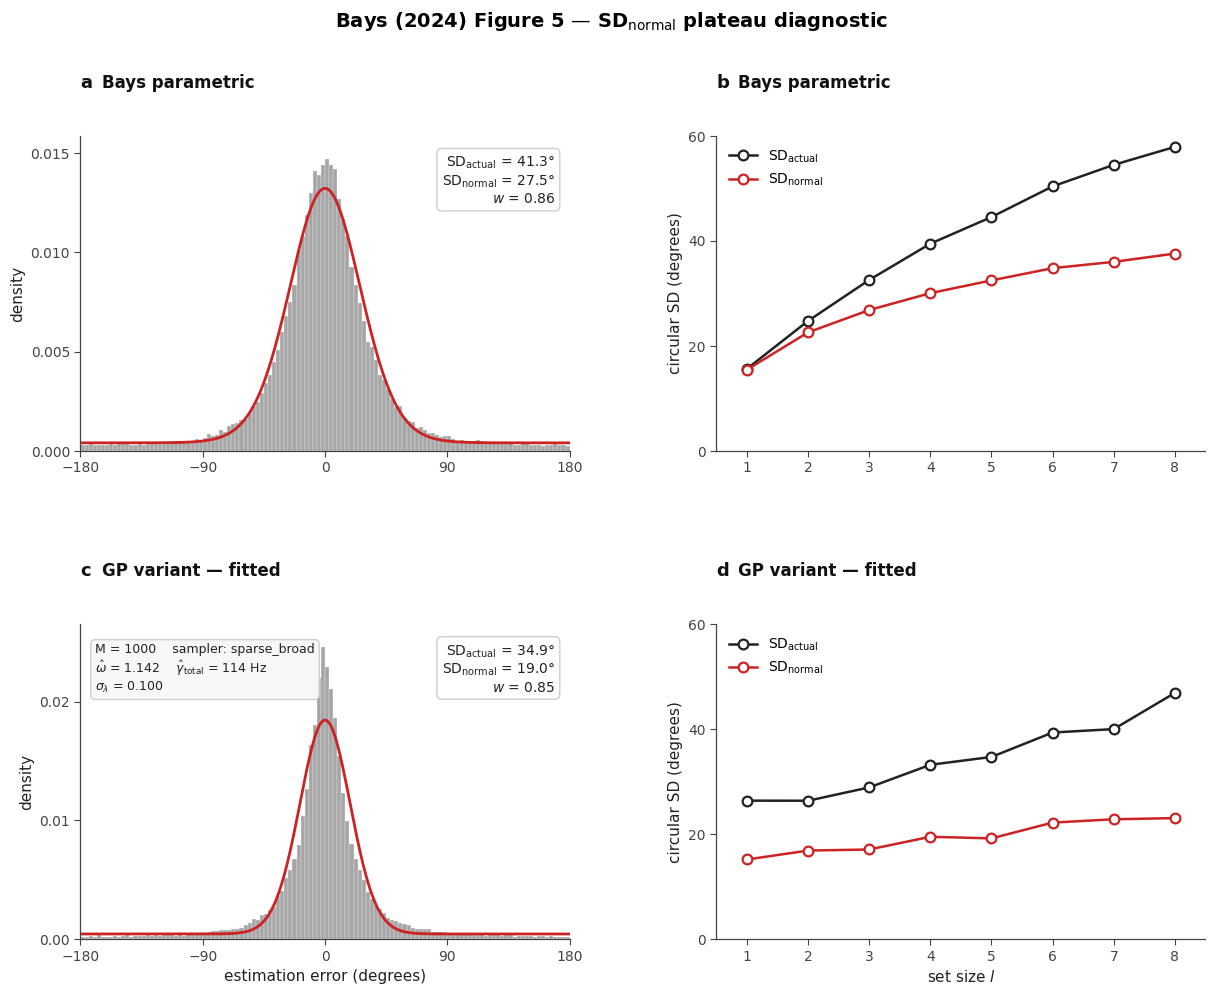

In [120]:
# Style -- match Bays Fig 5: SD_actual in black, SD_normal in red.
BLACK = "#222222"
RED   = "#CC2222"
GRAY  = "#777777"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "font.family": "DejaVu Sans",
})


def mixture_pdf(eps_rad, w, kappa):
    """Normal+uniform mixture density on the circle (input in radians)."""
    vm = np.exp(kappa * np.cos(eps_rad)) / (2.0 * np.pi * i0(kappa))
    return w * vm + (1.0 - w) * (1.0 / (2.0 * np.pi))


# Shared axes infrastructure
edges_deg    = np.linspace(-180, 180, HIST_N_BINS + 1)
eps_grid_deg = np.linspace(-180, 180, 500)
eps_grid_rad = np.deg2rad(eps_grid_deg)

ns = np.array(SET_SIZES, dtype=float)
sd_actual_bays = np.array([np.rad2deg(bays_results[N]["sd_actual"]) for N in SET_SIZES])
sd_normal_bays = np.array([np.rad2deg(bays_results[N]["sd_normal"]) for N in SET_SIZES])
sd_actual_gp   = np.array([np.rad2deg(gp_results[N]["sd_actual"])   for N in SET_SIZES])
sd_normal_gp   = np.array([np.rad2deg(gp_results[N]["sd_normal"])   for N in SET_SIZES])

# --- Refined y-axis for the SD-vs-l panels -----------------------------
y_max_raw = max(sd_actual_bays.max(), sd_actual_gp.max())
Y_TICK_STRIDE = 20
Y_MAX_B = int(np.ceil(y_max_raw / Y_TICK_STRIDE) * Y_TICK_STRIDE)
Y_TICKS_B = np.arange(0, Y_MAX_B + 1, Y_TICK_STRIDE)

# Suppress automatic grids in this style block
plt.rc("axes", grid=False)
# ----------------------------------------------------------------------

fig = plt.figure(figsize=(12.5, 10.5))
gs = gridspec.GridSpec(
    2, 2,
    hspace=0.55, wspace=0.30,
    left=0.075, right=0.975, bottom=0.075, top=0.84,
)


def _panel_header(ax, letter, model, caption, show_xlabel_pad=False):
    """Two-line panel header: bold letter + model on line 1, caption on line 2."""
    ax.set_title("")
    ax.text(
        0.0, 1.14, f"{letter}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=13, fontweight="bold", color="#111111",
    )
    ax.text(
        0.045, 1.14, model,
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, fontweight="bold", color="#111111",
    )
    ax.text(
        0.0, 1.02, caption,
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color="#555555",
    )


def plot_panel_a(ax, all_errors_rad, w, kappa, sd_actual_rad, sd_normal_rad,
                 letter, model, show_xlabel=True):
    """Aggregate error distribution + mixture overlay (degrees)."""
    all_errors_deg = np.rad2deg(all_errors_rad)
    counts, _, _ = ax.hist(all_errors_deg, bins=edges_deg, density=True,
            color=GRAY, alpha=0.65, edgecolor="white", linewidth=0.3)
    pdf_per_deg = mixture_pdf(eps_grid_rad, w, kappa) * (np.pi / 180.0)
    ax.plot(eps_grid_deg, pdf_per_deg, color=RED, lw=2.0)

    panel_y_max = max(counts.max(), pdf_per_deg.max()) * 1.08

    ax.set_xlim(-180, 180)
    ax.set_ylim(0, panel_y_max)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]))
    if show_xlabel:
        ax.set_xlabel("estimation error (degrees)", fontsize=11)
    ax.set_ylabel("density", fontsize=11)
    ax.grid(False)
    _panel_header(ax, letter, model, caption="")

    ax.text(
        0.97, 0.94,
        f"SD$_\\mathrm{{actual}}$ = {np.rad2deg(sd_actual_rad):.1f}\u00b0\n"
        f"SD$_\\mathrm{{normal}}$ = {np.rad2deg(sd_normal_rad):.1f}\u00b0\n"
        f"$w$ = {w:.2f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#222222",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#cccccc", alpha=0.95),
    )


def plot_panel_b(ax, sd_actual_arr, sd_normal_arr,
                 letter, model, show_xlabel=True):
    """SD_actual (black) vs SD_normal (red) across set sizes."""
    ax.plot(ns, sd_actual_arr, "o-", color=BLACK, lw=1.8, ms=7,
            label=r"SD$_\mathrm{actual}$", mfc="white", mew=1.6)
    ax.plot(ns, sd_normal_arr, "o-", color=RED, lw=1.8, ms=7,
            label=r"SD$_\mathrm{normal}$", mfc="white", mew=1.6)

    ax.set_xticks(SET_SIZES)
    ax.set_xlim(SET_SIZES[0] - 0.5, SET_SIZES[-1] + 0.5)
    ax.set_yticks(Y_TICKS_B)
    ax.set_ylim(0, Y_MAX_B)
    if show_xlabel:
        ax.set_xlabel("set size $l$", fontsize=11)
    ax.set_ylabel("circular SD (degrees)", fontsize=11)
    ax.legend(fontsize=10, loc="upper left", frameon=False)
    ax.grid(False)
    _panel_header(ax, letter, model, caption="")


# --- Row 1: Bays parametric ---
ax_1a = fig.add_subplot(gs[0, 0])
plot_panel_a(
    ax_1a, bays_all_errors, bays_w_agg, bays_kappa_agg,
    bays_sd_actual_agg, bays_sd_normal_agg,
    letter="a", model="Bays parametric",
    show_xlabel=False,
)

ax_1b = fig.add_subplot(gs[0, 1])
plot_panel_b(
    ax_1b, sd_actual_bays, sd_normal_bays,
    letter="b", model="Bays parametric",
    show_xlabel=False,
)

# --- Row 2: GP variant ---
# Panel labels now just say "GP variant — fitted". Sampler / M / fitted
# parameters live in the parameter callout below (on panel c) and in the
# figure's suptitle, not in the per-panel headers.
ax_2a = fig.add_subplot(gs[1, 0])
plot_panel_a(
    ax_2a, gp_all_errors, gp_w_agg, gp_kappa_agg,
    gp_sd_actual_agg, gp_sd_normal_agg,
    letter="c", model="GP variant — fitted",
    show_xlabel=True,
)

# Small parameter callout on panel c, lower-left, mirroring the
# SD/w callout already on the right. This is where the fitted-parameter
# numbers belong — in a small annotation, not in the title.
_sigma_label = {"folded_normal": r"$\sigma_\lambda$", "gamma": r"CV", "sparse_broad": r"$\sigma_\lambda$"}[DISTRIBUTION]
ax_2a.text(
    0.03, 0.94,
    f"M = {M}    sampler: {DISTRIBUTION}\n"
    f"$\\hat\\omega$ = {OMEGA_HAT:.3f}    "
    f"$\\hat\\gamma_\\mathrm{{total}}$ = {GAMMA_TOTAL_HAT:.0f} Hz\n"
    f"{_sigma_label} = {SIGMA_HAT:.3f}",
    transform=ax_2a.transAxes, ha="left", va="top",
    fontsize=9, color="#222222", family="DejaVu Sans",
    bbox=dict(boxstyle="round,pad=0.35", fc="#f7f7f7", ec="#cccccc", alpha=0.95),
)

ax_2b = fig.add_subplot(gs[1, 1])
plot_panel_b(
    ax_2b, sd_actual_gp, sd_normal_gp,
    letter="d", model="GP variant — fitted",
    show_xlabel=True,
)

# Figure-level heading — short, descriptive. No parameter dump.
fig.suptitle(
    r"Bays (2024) Figure 5 — SD$_\mathrm{normal}$ plateau diagnostic",
    fontsize=14, fontweight="bold", y=0.96,
)

# Save into the timestamped result directory
fig_path = OUTPUT_DIR / f"bays_fig5_M{M}_{DISTRIBUTION}.png"
fig_path_pdf = OUTPUT_DIR / f"bays_fig5_M{M}_{DISTRIBUTION}.pdf"
plt.savefig(fig_path,     dpi=160, bbox_inches="tight")
plt.savefig(fig_path_pdf,              bbox_inches="tight")
print(f"Saved {fig_path}")
print(f"Saved {fig_path_pdf}")
plt.show()


### Per-set-size error histograms — GP variant

A 1×5 strip showing the empirical error density for the GP forward model at
$\ell \in \{1, 2, 4, 6, 8\}$, with the fitted Zhang & Luck mixture overlaid in
red. Mirrors the panel-(a) style of the existing Bays vs GP figure, but
splits across set sizes instead of pooling.


Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/gp_error_histograms_M1000_sparse_broad.png


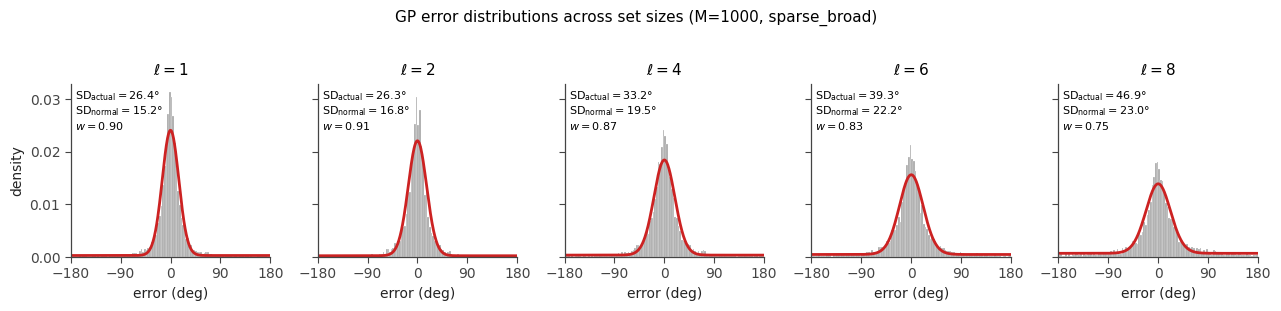

In [121]:
# Set sizes to display. Bays Fig 4 / Z&L convention: powers of two-ish.
HIST_SET_SIZES = [1, 2, 4, 6, 8]

# --- Self-contained plotting infrastructure --------------------------
# Mirror the pattern already used by the 8-panel comparison cell: define
# the shared histogram grid, the mixture density, and the colours locally
# so this cell runs on its own, regardless of whether the "Style" cell
# above was executed in the current kernel. (This is what previously
# caused a NameError on `edges_deg` after a kernel restart / out-of-order
# run.) When those names already exist, the values here are identical.
_n_bins = globals().get("HIST_N_BINS", 120)
edges_deg    = np.linspace(-180, 180, _n_bins + 1)
eps_grid_deg = np.linspace(-180, 180, 500)
eps_grid_rad = np.deg2rad(eps_grid_deg)

GRAY = globals().get("GRAY", "#777777")
RED  = globals().get("RED",  "#CC2222")

if "mixture_pdf" not in globals():
    def mixture_pdf(eps_rad, w, kappa):
        """Normal+uniform mixture density on the circle (input in radians)."""
        vm = np.exp(kappa * np.cos(eps_rad)) / (2.0 * np.pi * i0(kappa))
        return w * vm + (1.0 - w) * (1.0 / (2.0 * np.pi))
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(HIST_SET_SIZES),
    figsize=(2.6 * len(HIST_SET_SIZES), 3.0),
    sharey=True,
)

for ax, N in zip(axes, HIST_SET_SIZES):
    r = gp_results[N]
    errs_deg = np.rad2deg(r['errors'])

    # Gray histogram (matches panel a).
    ax.hist(errs_deg, bins=edges_deg, density=True,
            color=GRAY, alpha=0.65, edgecolor='white', linewidth=0.3)

    # Red mixture overlay — convert per-radian PDF to per-degree.
    pdf_per_deg = mixture_pdf(eps_grid_rad, r['w'], r['kappa']) * (np.pi / 180.0)
    ax.plot(eps_grid_deg, pdf_per_deg, color=RED, lw=2.0)

    ax.set_title(rf'$\ell = {N}$', fontsize=11)
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlabel(r'error (deg)')

    ax.text(
        0.02, 0.97,
        f'$\\mathrm{{SD}}_\\mathrm{{actual}}={np.rad2deg(r["sd_actual"]):.1f}\\degree$\n'
        f'$\\mathrm{{SD}}_\\mathrm{{normal}}={np.rad2deg(r["sd_normal"]):.1f}\\degree$\n'
        f'$w={r["w"]:.2f}$',
        transform=ax.transAxes, fontsize=8, va='top', ha='left',
    )

axes[0].set_ylabel('density')
fig.suptitle(
    f'GP error distributions across set sizes '
    f'(M={M}, {DISTRIBUTION})',
    y=1.02, fontsize=11,
)
fig.tight_layout()

hist_path = OUTPUT_DIR / f'gp_error_histograms_M{M}_{DISTRIBUTION}.png'
fig.savefig(hist_path, dpi=180, bbox_inches='tight')
print(f'Wrote {hist_path}')
plt.show()


### Diagnostic moments vs set size — sweep one parameter at a time

A 3×3 grid:

- **Columns**: A) circular variance, B) circular kurtosis (Fisher 1995), C)
  $w_\mathrm{uniform} = 1 - w_\mathrm{vM}$ from the Zhang & Luck fit.
- **Rows**: each row varies *one* model parameter, holding the other two at
  the fitted values $(\hat{\lambda}, \hat{\gamma}, \hat{\sigma})$ from the GP
  fit cell above. Top row: $\lambda$. Middle row: $\gamma_{\text{per neuron}}$.
  Bottom row: $\sigma$ — the mixed-selectivity knob ($\sigma_\lambda$ for
  folded-normal, CV for gamma, an analogous spread parameter for the
  random-vector sampler).

The bottom row is the diagnostic of primary interest: how does the gap
between actual and Zhang & Luck SDs (and the implied tail mass) respond to
the heterogeneity parameter itself?


In [122]:
# === One-parameter sweeps for the diagnostic grid ===
# Produces the arrays the transposed plot consumes:
#   sweep_lambda/gamma/sigma : shape (n_values, n_set_sizes, 3)
#   LAMBDA_SWEEP/GAMMA_SWEEP/SIGMA_SWEEP : the swept values
# Third axis is the metric: 0=circular variance, 1=circular kurtosis, 2=(1-w_vM).
# Each row varies ONE parameter, holding the other two at the fitted
# (LAMBDA_HAT, GAMMA_HAT, SIGMA_HAT) from the Step-1 fit above.

SWEEP_N_TRIALS = N_TRIALS     # trials per (value, set size); lower to go faster

def _circ_variance(errors):
    R = np.abs(np.mean(np.exp(1j * np.asarray(errors))))
    return -2.0 * np.log(max(R, 1e-15))

def _circ_kurtosis(errors):
    e = np.asarray(errors)
    m1, m2 = np.mean(np.exp(1j * e)), np.mean(np.exp(2j * e))
    rho1 = np.abs(m1)
    num = np.abs(m2) * np.cos(np.angle(m2) - 2 * np.angle(m1)) - rho1 ** 4
    den = (1.0 - rho1) ** 2
    return num / den

def _metrics_from_errors(errors):
    """(circular variance, circular kurtosis, 1 - w_vM) for one error pool."""
    w_hat, _kappa, _sd = fit_normal_uniform_mixture(errors)
    return _circ_variance(errors), _circ_kurtosis(errors), 1.0 - w_hat

def _errors_for(pop, set_size, gamma):
    """Run the trial engine exactly as the fit/Step-2 cells do, pinned RNG."""
    rng = np.random.RandomState(SEED + set_size)
    return pop.run_trials(
        n_trials=SWEEP_N_TRIALS, gamma=gamma, T_d=T_D, set_size=set_size,
        sigma_sq=SIGMA_SQ, rng=rng,
        active_locations=tuple(range(set_size)), probe_cued=True,
    )

# --- Swept value grids, anchored on the fitted values, clipped to fit bounds. ---
LAMBDA_SWEEP = np.clip(LAMBDA_HAT * np.array([0.6, 0.8, 1.0, 1.3]), LO[0], HI[0])
GAMMA_SWEEP  = np.clip(GAMMA_PER_NEURON_SWEEP  * np.array([0.5, 0.75, 1.0, 1.5]), LO[1], HI[1])
if SIGMA_NAME == 'cv':
    SIGMA_SWEEP = np.clip(np.array([0.05, 0.2, 0.5, 1.0]), LO[2], HI[2])
else:  # sigma_lambda (folded_normal / sparse_broad)
    SIGMA_SWEEP = np.clip(np.array([0.0, 0.1, 0.3, 0.6]), LO[2], HI[2])

n_ss = len(SET_SIZES)
sweep_lambda = np.empty((len(LAMBDA_SWEEP), n_ss, 3))
sweep_gamma  = np.empty((len(GAMMA_SWEEP),  n_ss, 3))
sweep_sigma  = np.empty((len(SIGMA_SWEEP),  n_ss, 3))

t0 = time.time()
print(f'Sweeping (held at lambda_hat={LAMBDA_HAT:.3f}, gamma/neuron={GAMMA_PER_NEURON_SWEEP:.3f}, '
      f'{SIGMA_NAME}_hat={SIGMA_HAT:.3f}); {SWEEP_N_TRIALS} trials/point.')

# Row 1: vary lambda (rebuild population per value; omega = lambda**2).
print('  lambda sweep...')
for j, lam in enumerate(LAMBDA_SWEEP):
    pop = build_gp_population(
        M=M, n_theta=N_THETA_GP, omega=lam ** 2, n_locations=max(SET_SIZES),
        seed=SEED, lengthscale_variability=SIGMA_HAT,
        gain_variability=GAIN_VARIABILITY, method=DISTRIBUTION,
    )
    for k, N in enumerate(SET_SIZES):
        sweep_lambda[j, k, :] = _metrics_from_errors(_errors_for(pop, N, GAMMA_PER_NEURON_SWEEP))

# Row 2: vary gamma (population is fixed; only the per-neuron gain changes).
print('  gamma sweep...')
pop_fixed = build_gp_population(
    M=M, n_theta=N_THETA_GP, omega=OMEGA_HAT, n_locations=max(SET_SIZES),
    seed=SEED, lengthscale_variability=SIGMA_HAT,
    gain_variability=GAIN_VARIABILITY, method=DISTRIBUTION,
)
for j, gam in enumerate(GAMMA_SWEEP):
    for k, N in enumerate(SET_SIZES):
        sweep_gamma[j, k, :] = _metrics_from_errors(_errors_for(pop_fixed, N, gam))

# Row 3: vary sigma / cv (rebuild population per value).
print('  sigma sweep...')
for j, sig in enumerate(SIGMA_SWEEP):
    pop = build_gp_population(
        M=M, n_theta=N_THETA_GP, omega=OMEGA_HAT, n_locations=max(SET_SIZES),
        seed=SEED, lengthscale_variability=sig,
        gain_variability=GAIN_VARIABILITY, method=DISTRIBUTION,
    )
    for k, N in enumerate(SET_SIZES):
        sweep_sigma[j, k, :] = _metrics_from_errors(_errors_for(pop, N, GAMMA_PER_NEURON_SWEEP))

print(f'Sweeps done in {time.time() - t0:.1f}s.')
print(f'  LAMBDA_SWEEP = {np.round(LAMBDA_SWEEP, 3)}')
print(f'  GAMMA_SWEEP  = {np.round(GAMMA_SWEEP, 3)}')
print(f'  SIGMA_SWEEP  = {np.round(SIGMA_SWEEP, 3)}  ({SIGMA_NAME})')


Sweeping (held at lambda_hat=1.069, gamma/neuron=0.114, sigma_lambda_hat=0.100); 5000 trials/point.
  lambda sweep...
  gamma sweep...
  sigma sweep...
Sweeps done in 148.0s.
  LAMBDA_SWEEP = [0.641 0.855 1.069 1.389]
  GAMMA_SWEEP  = [0.057 0.085 0.114 0.171]
  SIGMA_SWEEP  = [0.  0.1 0.3 0.6]  (sigma_lambda)



Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/gp_sweep_var_kurt_wuni_M1000_sparse_broad.png


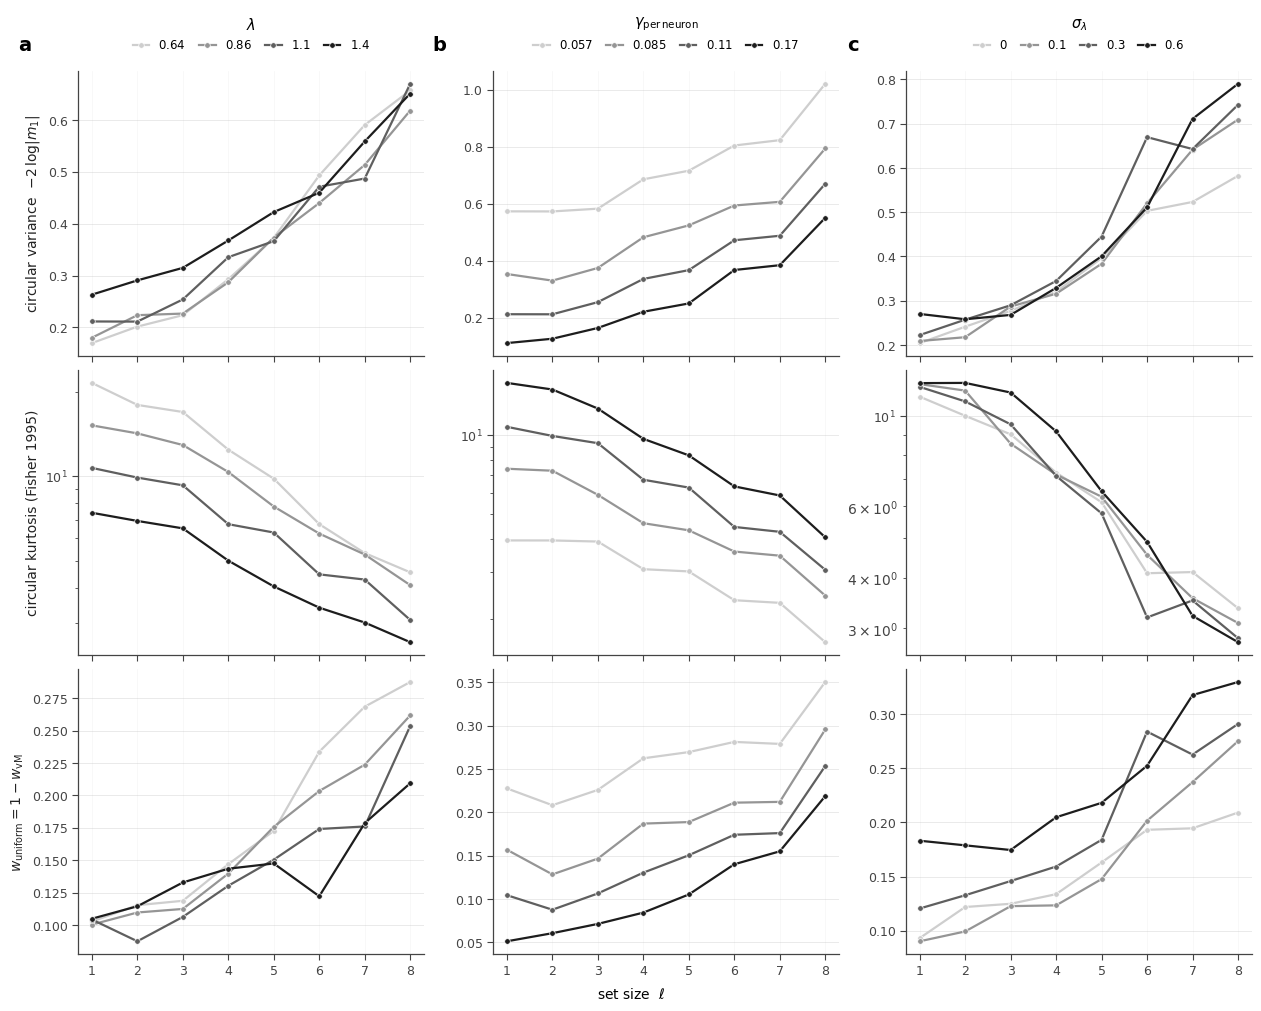

In [123]:
# Plot ---------------------------------------------------------------------
# TRANSPOSED LAYOUT: metrics are the 3 ROWS, the swept parameter is the
# 3 COLUMNS. The third axis (ci) of each sweep_* array is the metric index
# 0=variance, 1=kurtosis, 2=(1-w).
import matplotlib as mpl

# Display symbol for the heterogeneity knob (the sigma column).
_sigma_escaped = SIGMA_NAME.replace("_", r"\_")
SIGMA_SYM = {
    'sigma_lambda': r'\sigma_\lambda',
    'cv':           r'\mathrm{CV}',
}.get(SIGMA_NAME, r'\sigma_{\mathrm{' + _sigma_escaped + r'}}')

# --- One entry per swept parameter -> these are the COLUMNS. ---
#   (array, swept_values, latex symbol)
COLS = [
    (sweep_lambda, LAMBDA_SWEEP, r'\lambda'),
    (sweep_gamma,  GAMMA_SWEEP,  r'\gamma_{\mathrm{per\,neuron}}'),
    (sweep_sigma,  SIGMA_SWEEP,  SIGMA_SYM),
]
COL_LABELS = ['a', 'b', 'c']

# --- One entry per METRIC -> these are the ROWS (ci index, label, yscale). ---
ROWS = [
    (0, r'circular variance  $-2\,\log|m_1|$',      'linear'),
    (1, r'circular kurtosis (Fisher 1995)',         'log'),
    (2, r'$w_\mathrm{uniform} = 1 - w_\mathrm{vM}$', 'linear'),
]

# --- Monochrome grey ramp: light = low value, dark = high value. ---
# Shared across all three columns, so lightness always reads as "position in
# the swept range". Sampled off the ends of Greys to avoid invisible-white
# and pure-black extremes.
_GREYS = mpl.colormaps['Greys']
def _grey_ramp(k):
    if k <= 1:
        return [_GREYS(0.62)]
    return [_GREYS(0.30 + 0.60 * j / (k - 1)) for j in range(k)]

# --- Aesthetic direction: clean editorial look, restrained grid, type-led. ---
mpl.rcParams.update({
    'font.size':       10,
    'axes.edgecolor':  '#444444',
    'axes.linewidth':  0.9,
    'axes.labelcolor': '#222222',
    'xtick.color':     '#444444',
    'ytick.color':     '#444444',
    'legend.frameon':  False,
})

fig, axes = plt.subplots(3, 3, figsize=(12.5, 10.0), sharex=True,
                         constrained_layout=True)

for ci_row, (metric_idx, metric_long, yscale) in enumerate(ROWS):
    for cj, (grid, values, sym) in enumerate(COLS):
        ax = axes[ci_row, cj]
        colors = _grey_ramp(len(values))
        for j, v in enumerate(values):
            ax.plot(SET_SIZES, grid[j, :, metric_idx],
                    marker='o', ms=4.0, lw=1.6, color=colors[j],
                    markeredgecolor='white', markeredgewidth=0.5,
                    label=f'${v:.2g}$', zorder=3)
        ax.set_yscale(yscale)
        ax.set_xticks(SET_SIZES)
        ax.set_xlim(min(SET_SIZES) - 0.3, max(SET_SIZES) + 0.3)
        ax.grid(True, which='major', axis='y', alpha=0.30, lw=0.6)
        ax.grid(True, which='major', axis='x', alpha=0.12, lw=0.5)
        ax.tick_params(axis='both', labelsize=9)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        # Y label only on the leftmost column: the metric for this row.
        if cj == 0:
            ax.set_ylabel(metric_long, fontsize=10)

# --- One legend per column, above each column: symbol as the title, ---
# --- values as the entries (no "= ", no "sweep"). --------------------
for cj, (grid, values, sym) in enumerate(COLS):
    handles, labels = axes[0, cj].get_legend_handles_labels()
    axes[0, cj].legend(
        handles, labels,
        loc='lower center', bbox_to_anchor=(0.5, 1.03),
        ncol=min(len(values), 4), fontsize=8.5,
        columnspacing=1.1, handlelength=1.4,
        title=rf'${sym}$', title_fontsize=10.5,
    )
    # Column label a / b / c at the top-left of the column.
    axes[0, cj].annotate(
        COL_LABELS[cj],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(-34, 12), textcoords='offset points',
        ha='right', va='bottom', fontsize=14, fontweight='bold',
    )

# --- Single shared x-label for the whole grid. ---
fig.supxlabel(r'set size  $\ell$', fontsize=10)

sweep_path = OUTPUT_DIR / f'gp_sweep_var_kurt_wuni_M{M}_{DISTRIBUTION}.png'
fig.savefig(sweep_path, dpi=180, bbox_inches='tight')
print(f'\nWrote {sweep_path}')
plt.show()

## GP Analysis

**Experiment 2.** A four-panel summary of the GP variant's error structure and diagnostics, drawn entirely from the GP pipeline outputs computed above (`gp_results`, the aggregate fit, and the set-size sweep). Four graphs in one figure, laid out on a 2×2 grid:

1. **Aggregate error histogram** — GP errors pooled across all set sizes, with the fitted Zhang & Luck mixture overlaid (same as panel (c) of the comparison figure).
2. **Single-item histogram** — the error distribution for $\ell = 1$ alone.
3. **SD line plot** — $\mathrm{SD}_{\mathrm{actual}}$ vs $\mathrm{SD}_{\mathrm{normal}}$ across set sizes (the plateau diagnostic).
4. **Weight line plot** — the mixture weight $w$ (stored fraction) as a function of set size.

Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2024/result_data/bays_fig5_20260806_233750_6dc0e687/bays_vs_gp_8panel_M1000_sparse_broad.png


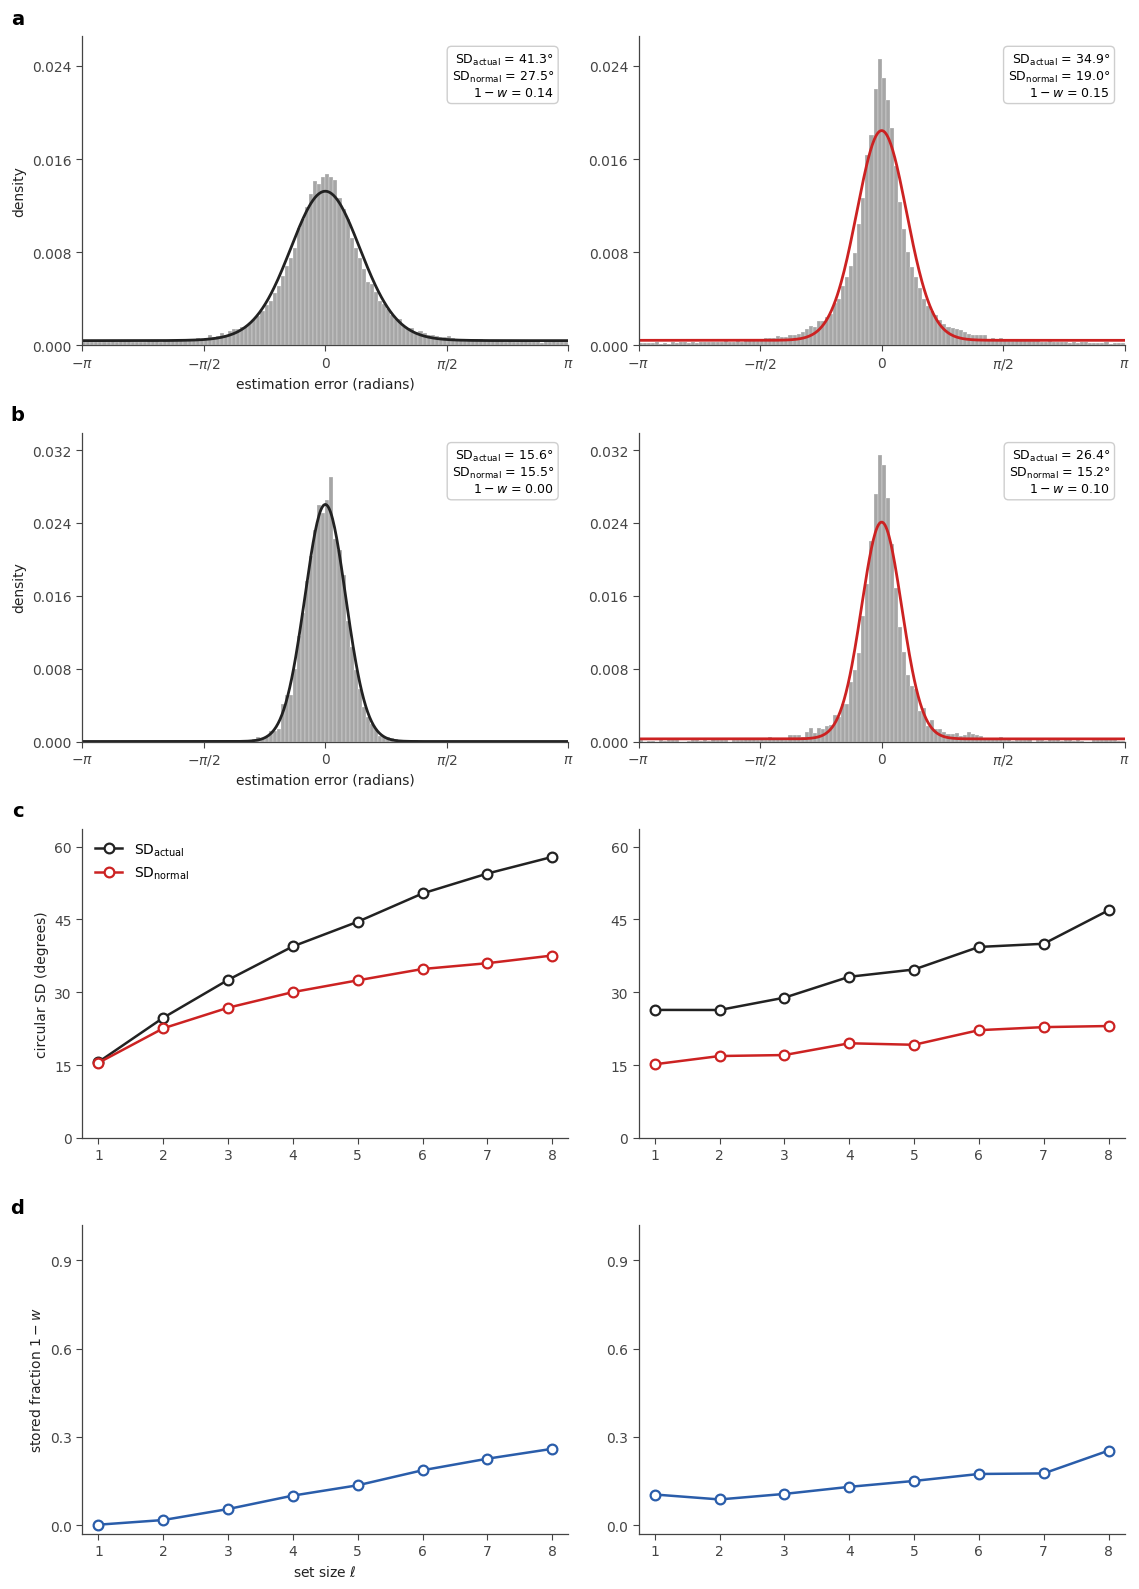

In [124]:
# === Bays vs GP - eight-panel comparison (4x2 grid) ===
from scipy.special import i0 as _i0
from matplotlib.ticker import MaxNLocator

GRAY  = "#777777"
RED   = "#CC2222"
BLACK = "#222222"
BLUE  = "#2A5DAA"


def _mixture_pdf(eps_rad, w, kappa):
    """Normal+uniform mixture density on the circle (radians)."""
    vm = np.exp(kappa * np.cos(eps_rad)) / (2.0 * np.pi * _i0(kappa))
    return w * vm + (1.0 - w) * (1.0 / (2.0 * np.pi))


_edges_deg    = np.linspace(-180, 180, HIST_N_BINS + 1)
_eps_grid_deg = np.linspace(-180, 180, 500)
_eps_grid_rad = np.deg2rad(_eps_grid_deg)
_deg_scale    = np.pi / 180.0

_ns = np.array(SET_SIZES, dtype=float)


def _sd_actual_curve(res):
    return np.array([np.rad2deg(res[N]["sd_actual"]) for N in SET_SIZES])

def _sd_normal_curve(res):
    return np.array([np.rad2deg(res[N]["sd_normal"]) for N in SET_SIZES])

def _stored_curve(res):
    return np.array([1.0 - res[N]["w"] for N in SET_SIZES])


bays_sd_a, bays_sd_n = _sd_actual_curve(bays_results), _sd_normal_curve(bays_results)
gp_sd_a,   gp_sd_n   = _sd_actual_curve(gp_results),   _sd_normal_curve(gp_results)
bays_stored, gp_stored = _stored_curve(bays_results), _stored_curve(gp_results)


def _hist_peak(errors, w, kappa):
    dens, _ = np.histogram(np.rad2deg(errors), bins=_edges_deg, density=True)
    pdf = _mixture_pdf(_eps_grid_rad, w, kappa) * _deg_scale
    return max(dens.max(), pdf.max())

_b1, _g1 = bays_results[1], gp_results[1]

agg_top = max(_hist_peak(bays_all_errors, bays_w_agg, bays_kappa_agg),
              _hist_peak(gp_all_errors,   gp_w_agg,   gp_kappa_agg)) * 1.08
l1_top  = max(_hist_peak(_b1["errors"], _b1["w"], _b1["kappa"]),
              _hist_peak(_g1["errors"], _g1["w"], _g1["kappa"])) * 1.08

sd_top  = max(bays_sd_a.max(), bays_sd_n.max(),
              gp_sd_a.max(), gp_sd_n.max()) * 1.10

xlim_setsize = (SET_SIZES[0] - 0.25, SET_SIZES[-1] + 0.25)


fig, axes = plt.subplots(4, 2, figsize=(11.5, 16.0))


# --- helpers -------------------------------------------------------------
# show_xlabel / show_ylabel let us put the axis-title text on the LEFT column
# only (ticks stay on every panel; the right column's redundant titles are
# suppressed).
def _draw_hist(ax, errors, w, kappa, ytop, curve_color=RED,
               show_xlabel=True, show_ylabel=True):
    ax.hist(np.rad2deg(errors), bins=_edges_deg, density=True,
            color=GRAY, alpha=0.65, edgecolor="white", linewidth=0.3)
    pdf = _mixture_pdf(_eps_grid_rad, w, kappa) * _deg_scale
    ax.plot(_eps_grid_deg, pdf, color=curve_color, lw=2.0)
    ax.set_xlim(-180, 180)
    # Data stay binned/plotted in degrees exactly as before; only the tick
    # *labels* are rewritten in radians (positions unchanged), so nothing that
    # is plotted moves. -180/-90/0/90/180 deg  ->  -pi / -pi/2 / 0 / pi/2 / pi.
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
    ax.set_ylim(0.0, ytop)
    if show_xlabel:
        ax.set_xlabel("estimation error (radians)")
    if show_ylabel:
        ax.set_ylabel("density")

def _thin_yticks(ax, reduce_by=2, min_ticks=3):
    """Aesthetics only: reduce the number of visible y-ticks by `reduce_by`,
    keeping matplotlib's nice evenly-spaced round values and the exact axis
    limits. Lands exactly -reduce_by wherever round numbers permit; otherwise
    it snaps to the nearest reduction (biased toward fewer ticks). Nothing
    plotted and no axis limit is changed."""
    lo, hi = ax.get_ylim()
    inview = lambda ts: [t for t in ts if lo - 1e-9 <= t <= hi + 1e-9]
    before = len(inview(ax.get_yticks()))
    desired = max(before - reduce_by, min_ticks)
    best = None
    for nb in range(1, before + 3):
        cnt = len(inview(MaxNLocator(nbins=nb).tick_values(lo, hi)))
        key = (cnt != desired, abs(cnt - desired), cnt > desired)
        if best is None or key < best[0]:
            best = (key, nb)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=best[1]))
    ax.set_ylim(lo, hi)

def _annot(ax, sd_a, sd_n, w):
    ax.text(
        0.97, 0.95,
        f"SD$_\\mathrm{{actual}}$ = {np.rad2deg(sd_a):.1f}\u00b0\n"
        f"SD$_\\mathrm{{normal}}$ = {np.rad2deg(sd_n):.1f}\u00b0\n"
        f"$1-w$ = {1.0 - w:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#cccccc", alpha=0.95),
    )

def _draw_sd(ax, sd_a, sd_n, show_xlabel=True, show_ylabel=True, show_legend=True):
    ax.plot(_ns, sd_a, "o-", color=BLACK, lw=1.8, ms=7,
            label=r"SD$_\mathrm{actual}$", mfc="white", mew=1.6)
    ax.plot(_ns, sd_n, "o-", color=RED, lw=1.8, ms=7,
            label=r"SD$_\mathrm{normal}$", mfc="white", mew=1.6)
    ax.set_xticks(SET_SIZES)
    ax.set_xlim(*xlim_setsize)
    ax.set_ylim(0.0, sd_top)
    if show_xlabel:
        ax.set_xlabel(r"set size $\ell$")
    if show_ylabel:
        ax.set_ylabel("circular SD (degrees)")
    if show_legend:
        ax.legend(fontsize=10, loc="upper left", frameon=False)

def _draw_stored(ax, stored, color, show_xlabel=True, show_ylabel=True):
    ax.plot(_ns, stored, "o-", color=color, lw=1.8, ms=7,
            mfc="white", mew=1.6, clip_on=False, zorder=3)
    ax.set_xticks(SET_SIZES)
    ax.set_xlim(*xlim_setsize)
    ax.set_ylim(-0.03, 1.02)
    if show_xlabel:
        ax.set_xlabel(r"set size $\ell$")
    if show_ylabel:
        ax.set_ylabel(r"stored fraction $1-w$")


# --- Row 1: aggregate ("collated") histograms --------------------------
# Left panel carries both axis titles; right panel bare.
_draw_hist(axes[0, 0], bays_all_errors, bays_w_agg, bays_kappa_agg, agg_top,
           curve_color=BLACK, show_xlabel=True, show_ylabel=True)
_annot(axes[0, 0], bays_sd_actual_agg, bays_sd_normal_agg, bays_w_agg)

_draw_hist(axes[0, 1], gp_all_errors, gp_w_agg, gp_kappa_agg, agg_top,
           show_xlabel=False, show_ylabel=False)   # GP stays red
_annot(axes[0, 1], gp_sd_actual_agg, gp_sd_normal_agg, gp_w_agg)

# --- Row 2: single-item histograms (l = 1) -----------------------------
# Left panel carries both axis titles; right panel bare.
_draw_hist(axes[1, 0], _b1["errors"], _b1["w"], _b1["kappa"], l1_top,
           curve_color=BLACK, show_xlabel=True, show_ylabel=True)
_annot(axes[1, 0], _b1["sd_actual"], _b1["sd_normal"], _b1["w"])

_draw_hist(axes[1, 1], _g1["errors"], _g1["w"], _g1["kappa"], l1_top,
           show_xlabel=False, show_ylabel=False)    # GP stays red
_annot(axes[1, 1], _g1["sd_actual"], _g1["sd_normal"], _g1["w"])

# --- Row 3: SD_actual vs SD_normal -------------------------------------
# y-label + legend once, on the left; set-size x-label deferred to row 4.
_draw_sd(axes[2, 0], bays_sd_a, bays_sd_n,
         show_xlabel=False, show_ylabel=True, show_legend=True)
_draw_sd(axes[2, 1], gp_sd_a, gp_sd_n,
         show_xlabel=False, show_ylabel=False, show_legend=False)

# --- Row 4: stored fraction (1 - w) -- BLUE for both models ------------
# set-size x-label shown once here, on the left.
_draw_stored(axes[3, 0], bays_stored, BLUE, show_xlabel=True,  show_ylabel=True)
_draw_stored(axes[3, 1], gp_stored,   BLUE, show_xlabel=False, show_ylabel=False)

# --- Row labels: fixed point-offset from each panel's top-left corner ---
for _r, _lab in enumerate(["a", "b", "c", "d"]):
    axes[_r, 0].annotate(
        _lab,
        xy=(0, 1), xycoords="axes fraction",          # top-left corner of the panel
        xytext=(-42, 6), textcoords="offset points",  # fixed shift: left & up, in points
        ha="right", va="bottom", fontsize=14, fontweight="bold",
    )
fig.tight_layout()

# Aesthetics only: thin every panel's y-ticks by two (draw first so the
# default tick counts are realised, then re-locate). Limits/data untouched.
fig.canvas.draw()
for _ax in axes.flat:
    _thin_yticks(_ax, reduce_by=2)

bays_vs_gp_path = OUTPUT_DIR / f"bays_vs_gp_8panel_M{M}_{DISTRIBUTION}.png"
fig.savefig(bays_vs_gp_path, dpi=180, bbox_inches="tight")
print(f"Wrote {bays_vs_gp_path}")
plt.show()